# `seaborn.heatmap` (API page, not in the tutorial)

📄 Source: https://seaborn.pydata.org/generated/seaborn.heatmap.html

`sns.heatmap(data, ...)` plots rectangular data as a colour-encoded matrix. It's **axes-level** (accepts `ax=`, returns the `Axes`).

Key parameters (from the API page):

| Parameter | What it does |
| :-- | :-- |
| `data` | 2-D data; a DataFrame's index/columns become the row/column labels |
| `vmin`, `vmax` | values anchoring the colormap (otherwise inferred from the data) |
| `cmap` | colormap name or object |
| `center` | value at which to **centre** the colormap (diverging data; e.g. `center=0`) |
| `annot` | `True` → write the value in each cell; or an array/DataFrame of the same shape to write instead |
| `fmt` | string format for the annotations, e.g. `".2f"` |
| `linewidths`, `linecolor` | lines between cells |
| `cbar`, `cbar_kws` | draw the colorbar / keyword args for it |
| `square` | make each cell square |
| `mask` | `True` cells are **not** drawn (e.g. hide the upper triangle) |
| `ax` | the matplotlib Axes to draw on |

The examples at the bottom of the page:

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()
print("seaborn", sns.__version__)

seaborn 0.13.2


Pass a DataFrame: its index and columns become the row/column labels. (`glue` = scores of NLP models on benchmark tasks, pivoted to wide form.)

<Axes: xlabel='Task', ylabel='Model'>

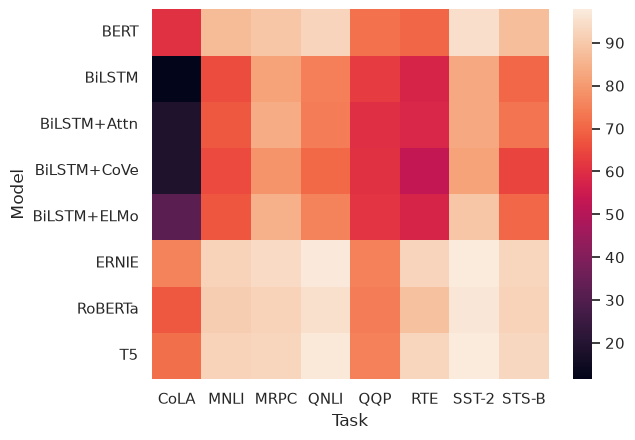

In [2]:
glue = sns.load_dataset("glue").pivot(index="Model", columns="Task", values="Score")
sns.heatmap(glue)

<Axes: xlabel='Task', ylabel='Model'>

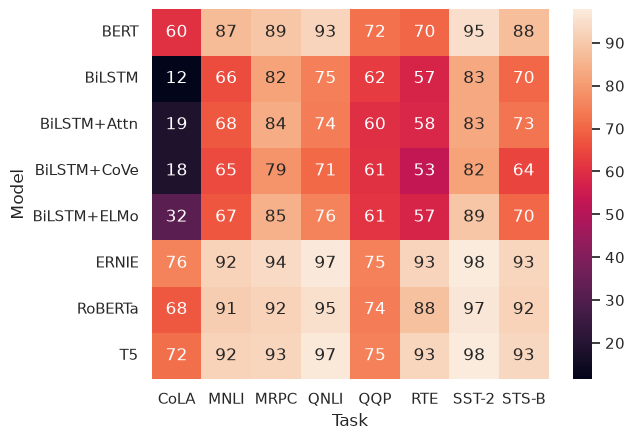

In [3]:
# annot: write the cell values as text
sns.heatmap(glue, annot=True)

<Axes: xlabel='Task', ylabel='Model'>

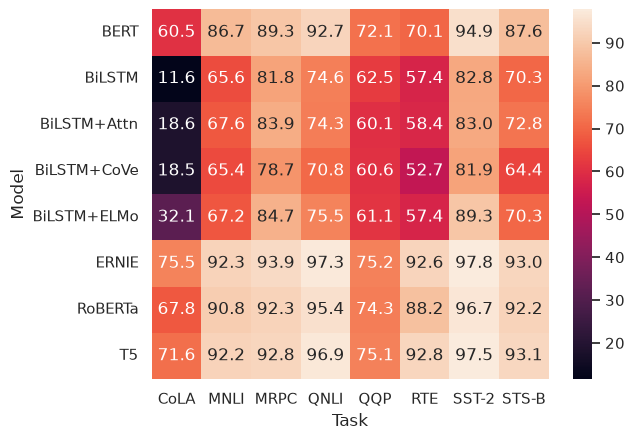

In [4]:
# fmt: control the annotation format (1 decimal)
sns.heatmap(glue, annot=True, fmt=".1f")

<Axes: xlabel='Task', ylabel='Model'>

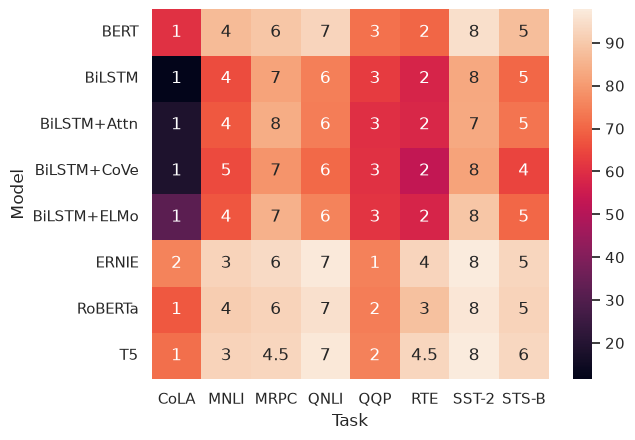

In [5]:
# A separate DataFrame for the annotations: here each model's rank within the task row
sns.heatmap(glue, annot=glue.rank(axis="columns"))

<Axes: xlabel='Task', ylabel='Model'>

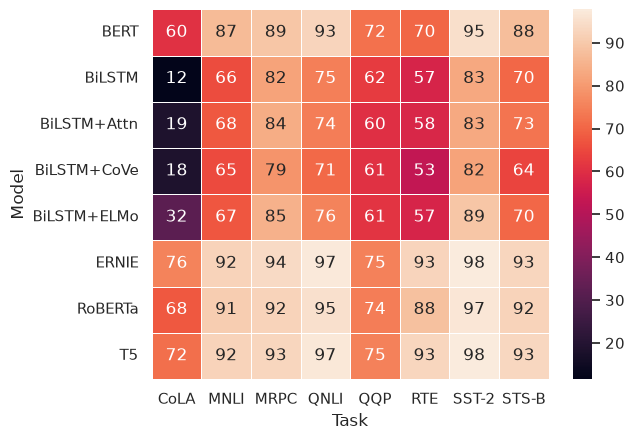

In [6]:
# Lines between cells
sns.heatmap(glue, annot=True, linewidth=.5)

<Axes: xlabel='Task', ylabel='Model'>

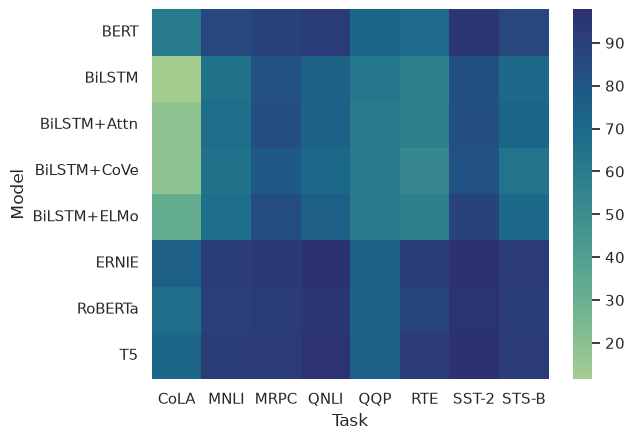

In [7]:
# A different colormap by name...
sns.heatmap(glue, cmap="crest")

<Axes: xlabel='Task', ylabel='Model'>

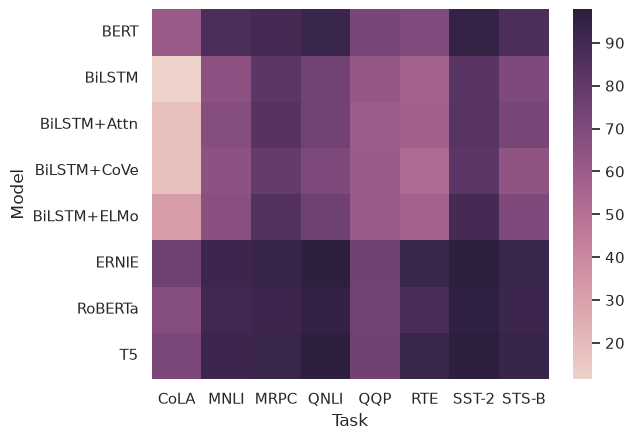

In [8]:
# ...or a colormap object
sns.heatmap(glue, cmap=sns.cubehelix_palette(as_cmap=True))

<Axes: xlabel='Task', ylabel='Model'>

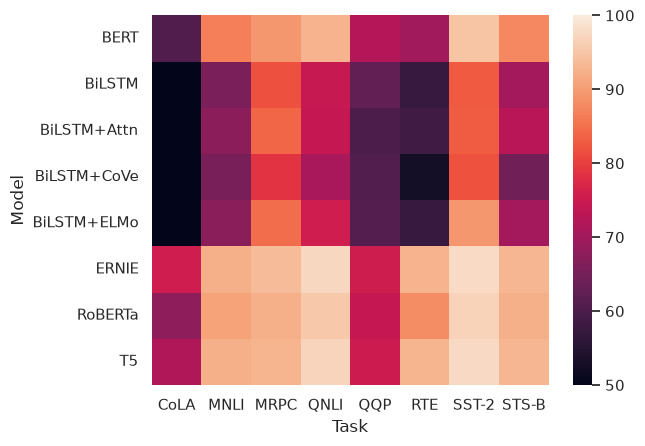

In [9]:
# vmin/vmax: the data values for the two ends of the colormap
sns.heatmap(glue, vmin=50, vmax=100)

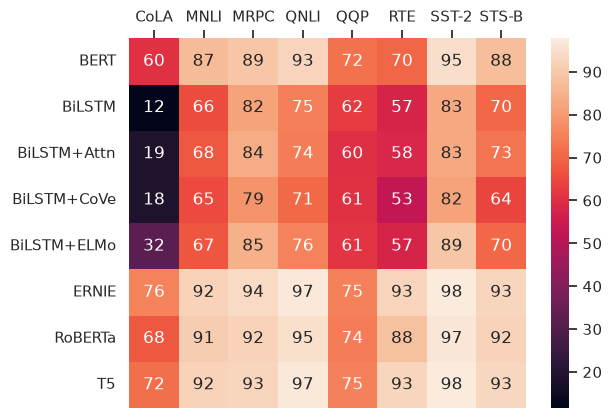

In [10]:
# It returns a matplotlib Axes, so use Axes methods to tweak it
ax = sns.heatmap(glue, annot=True)
ax.set(xlabel="", ylabel="")
ax.xaxis.tick_top()   # move the column labels to the top

## Roadmap chart #6: correlation heatmap (from the README)

Correlations go from -1 to +1 around a meaningful **0** → a **diverging** palette (`vlag`) with `center=0`, `vmin=-1`, `vmax=1`. A correlation matrix is symmetric, so `mask` hides the redundant upper triangle.

Text(0.0, 1.0, 'Flipper length and body mass move together (r = 0.87)')

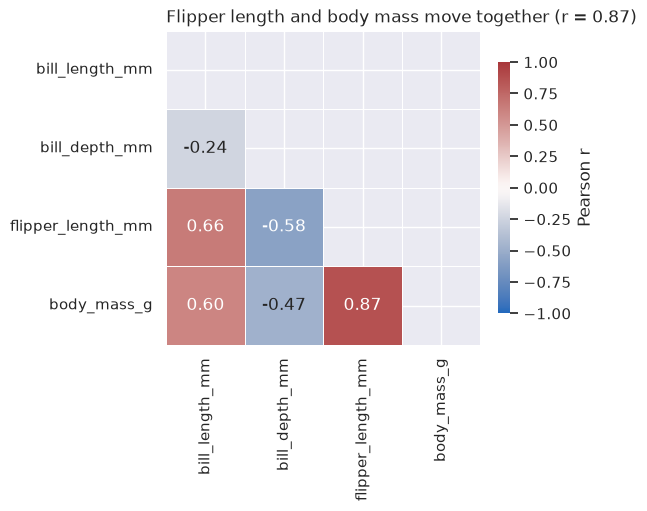

In [11]:
penguins = sns.load_dataset("penguins")
corr = penguins.corr(numeric_only=True)          # pairwise correlations of the numeric columns

mask = np.triu(np.ones_like(corr, dtype=bool))   # True on and above the diagonal -> not drawn

fig, ax = plt.subplots(figsize=(6, 5), layout="constrained")
sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", square=True, linewidths=.5,
            cbar_kws={"shrink": .8, "label": "Pearson r"}, ax=ax)
ax.set_title("Flipper length and body mass move together (r = 0.87)", loc="left")

The README's one-liner works too (without the mask):

<Axes: >

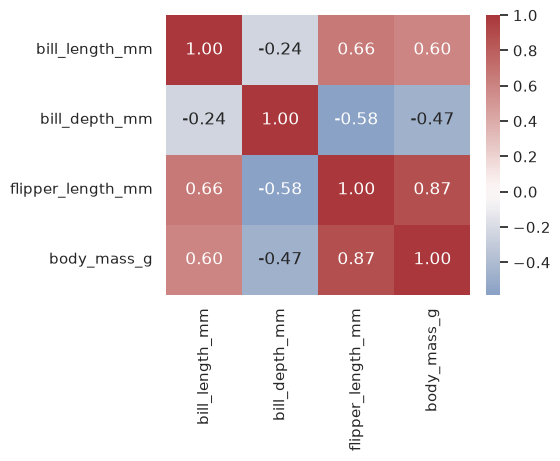

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4.5), layout="constrained")
sns.heatmap(penguins.corr(numeric_only=True), cmap="vlag", center=0, annot=True, fmt=".2f", ax=ax)

## Key takeaways

- `sns.heatmap(df)`: index → rows, columns → columns. Long data? `pivot` it first.
- Show values with `annot=True, fmt=".2f"`.
- Diverging data: `cmap="vlag"` (or `"RdBu_r"`), `center=0`, fixed `vmin`/`vmax`.
- Hide redundant cells with `mask=np.triu(...)`. It returns an `Axes`, so finish with matplotlib.